In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## 1. Cargar Scores del Validation Set

In [3]:
# Configurar la ruta del run a analizar
# Opción 1: Especificar ruta directa
RUN_NAME = 'resnet50_20260107_161001'  # Cambiar por el run deseado

# Opción 2: Usar el más reciente (comentar la línea anterior y descomentar estas)
# outputs_dir = Path('../outputs')
# RUN_NAME = sorted(outputs_dir.glob('resnet50_*'))[-1].name

outputs_dir = Path('../outputs')
latest_run = outputs_dir / RUN_NAME
scores_path = latest_run / 'prediction_scores_test.csv'

print(f"Cargando scores desde: {scores_path}")
df = pd.read_csv(scores_path)
print(f"Total de muestras: {len(df)}")
print(f"Benignas: {(df['true_label']==0).sum()}")
print(f"Malignas: {(df['true_label']==1).sum()}")
df.head()

Cargando scores desde: ../outputs/resnet50_20260107_161001/prediction_scores_test.csv
Total de muestras: 17125
Benignas: 15067
Malignas: 2058


,true_label,predicted_score
0,0,0.059106
1,0,0.489789
2,0,0.260948
3,0,0.271837
4,0,0.237906


## 2. Histograma de Distribución de Scores

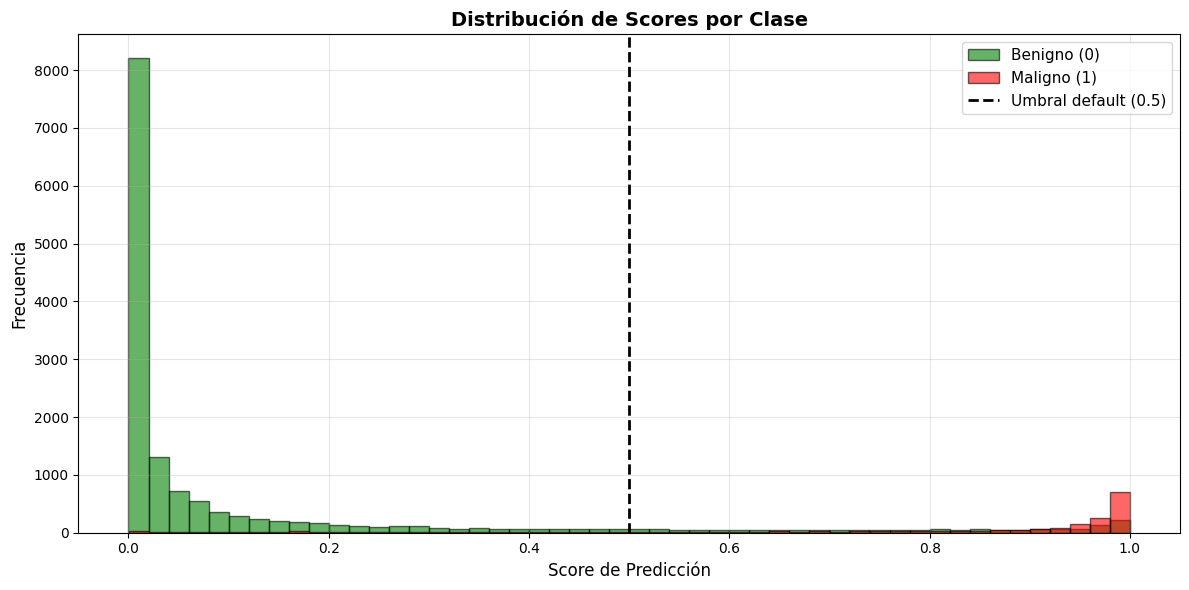


📊 Estadísticas de Scores:

Benignos:
  Media: 0.1330
  Mediana: 0.0138
  Std: 0.2504

Malignos:
  Media: 0.8029
  Mediana: 0.9515
  Std: 0.2830


In [4]:
# Separar scores por clase
scores_benign = df[df['true_label'] == 0]['predicted_score']
scores_malignant = df[df['true_label'] == 1]['predicted_score']

# Crear histograma
plt.figure(figsize=(12, 6))
plt.hist(scores_benign, bins=50, alpha=0.6, label='Benigno (0)', color='green', edgecolor='black')
plt.hist(scores_malignant, bins=50, alpha=0.6, label='Maligno (1)', color='red', edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral default (0.5)')
plt.xlabel('Score de Predicción', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Scores por Clase', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(latest_run / 'figures' / 'score_distribution.png', dpi=150)
plt.show()

print(f"\n📊 Estadísticas de Scores:")
print(f"\nBenignos:")
print(f"  Media: {scores_benign.mean():.4f}")
print(f"  Mediana: {scores_benign.median():.4f}")
print(f"  Std: {scores_benign.std():.4f}")
print(f"\nMalignos:")
print(f"  Media: {scores_malignant.mean():.4f}")
print(f"  Mediana: {scores_malignant.median():.4f}")
print(f"  Std: {scores_malignant.std():.4f}")

## 3. Análisis de Umbrales

Probar diferentes umbrales para encontrar el punto óptimo de balance.

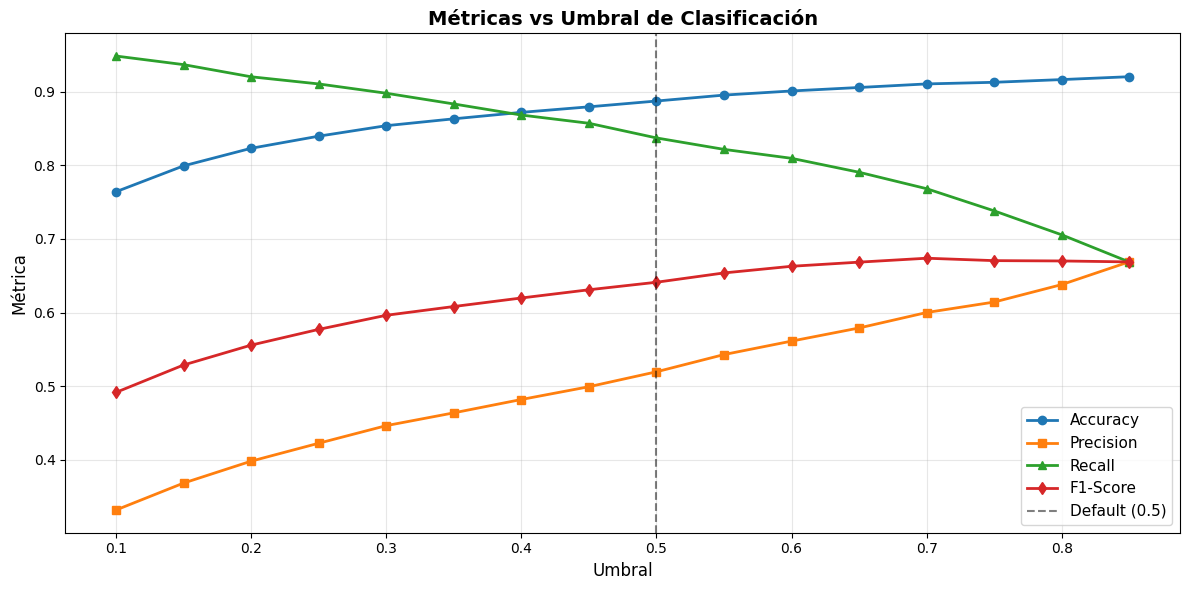


🎯 Umbrales Recomendados:

Mejor F1-Score: 0.70
  Accuracy: 0.9106
  Precision: 0.6000
  Recall: 0.7682
  F1: 0.6738

Mejor Accuracy: 0.85
  Accuracy: 0.9204
  Precision: 0.6689
  Recall: 0.6686
  F1: 0.6688


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Probar diferentes umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds:
    y_pred = (df['predicted_score'] >= threshold).astype(int)
    y_true = df['true_label']
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

# Graficar métricas vs umbral
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(results_df['threshold'], results_df['accuracy'], 'o-', label='Accuracy', linewidth=2)
ax.plot(results_df['threshold'], results_df['precision'], 's-', label='Precision', linewidth=2)
ax.plot(results_df['threshold'], results_df['recall'], '^-', label='Recall', linewidth=2)
ax.plot(results_df['threshold'], results_df['f1'], 'd-', label='F1-Score', linewidth=2)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.set_xlabel('Umbral', fontsize=12)
ax.set_ylabel('Métrica', fontsize=12)
ax.set_title('Métricas vs Umbral de Clasificación', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(latest_run / 'figures' / 'threshold_analysis.png', dpi=150)
plt.show()

# Encontrar mejores umbrales
best_f1_idx = results_df['f1'].idxmax()
best_acc_idx = results_df['accuracy'].idxmax()

print(f"\n🎯 Umbrales Recomendados:")
print(f"\nMejor F1-Score: {results_df.loc[best_f1_idx, 'threshold']:.2f}")
print(f"  Accuracy: {results_df.loc[best_f1_idx, 'accuracy']:.4f}")
print(f"  Precision: {results_df.loc[best_f1_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[best_f1_idx, 'recall']:.4f}")
print(f"  F1: {results_df.loc[best_f1_idx, 'f1']:.4f}")

print(f"\nMejor Accuracy: {results_df.loc[best_acc_idx, 'threshold']:.2f}")
print(f"  Accuracy: {results_df.loc[best_acc_idx, 'accuracy']:.4f}")
print(f"  Precision: {results_df.loc[best_acc_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[best_acc_idx, 'recall']:.4f}")
print(f"  F1: {results_df.loc[best_acc_idx, 'f1']:.4f}")

## 4. Tabla Completa de Resultados

In [6]:
# Mostrar tabla completa
results_df.style.highlight_max(subset=['accuracy', 'precision', 'recall', 'f1'], color='lightgreen')

,threshold,accuracy,precision,recall,f1
0,0.100000,0.764088,0.331634,0.948494,0.491440
1,0.150000,0.799241,0.368220,0.936832,0.528654
2,0.200000,0.823124,0.397983,0.920311,0.555670
3,0.250000,0.839591,0.422357,0.910593,0.577059
4,0.300000,0.853839,0.446269,0.897959,0.596225
5,0.350000,0.863182,0.463657,0.883382,0.608128
6,0.400000,0.871942,0.481801,0.868319,0.619733
7,0.450000,0.879474,0.499151,0.857143,0.630901
8,0.500000,0.887358,0.519445,0.837221,0.641116
9,0.550000,0.895416,0.542857,0.821672,0.653779


## 5. Visualización de Separación de Clases

/tmp/ipykernel_8089/509726732.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data_to_plot, labels=['Benigno', 'Maligno'], patch_artist=True,


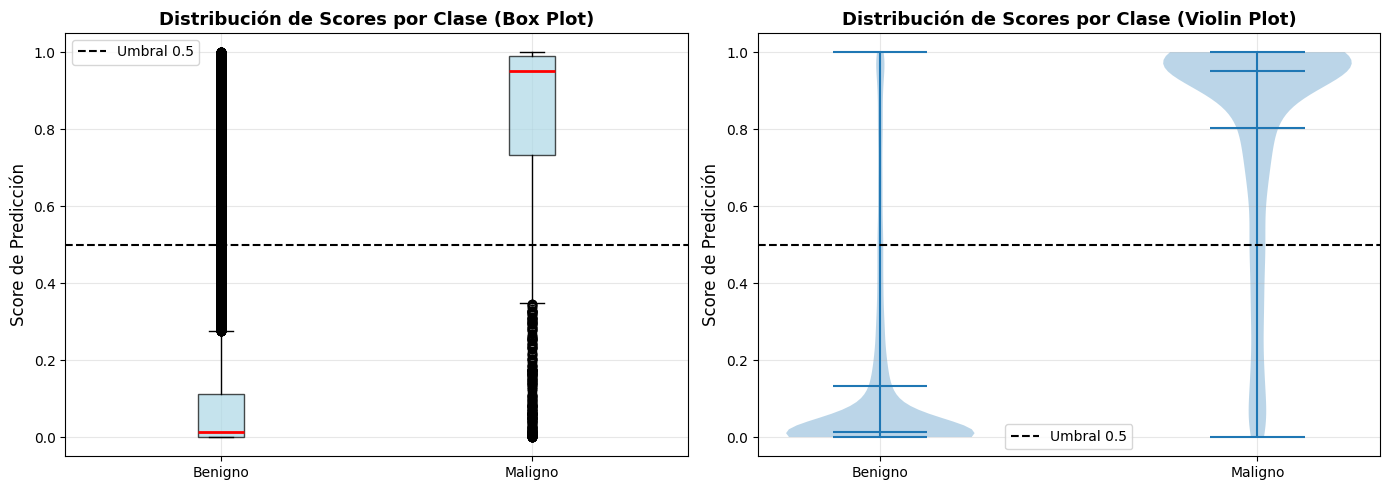

In [7]:
# Box plot para ver la separación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_to_plot = [scores_benign, scores_malignant]
ax1.boxplot(data_to_plot, labels=['Benigno', 'Maligno'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax1.axhline(y=0.5, color='black', linestyle='--', label='Umbral 0.5')
ax1.set_ylabel('Score de Predicción', fontsize=12)
ax1.set_title('Distribución de Scores por Clase (Box Plot)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Violin plot
positions = [1, 2]
parts = ax2.violinplot(data_to_plot, positions=positions, showmeans=True, showmedians=True)
ax2.axhline(y=0.5, color='black', linestyle='--', label='Umbral 0.5')
ax2.set_xticks(positions)
ax2.set_xticklabels(['Benigno', 'Maligno'])
ax2.set_ylabel('Score de Predicción', fontsize=12)
ax2.set_title('Distribución de Scores por Clase (Violin Plot)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(latest_run / 'figures' / 'score_separation.png', dpi=150)
plt.show()

## 6. Métricas Avanzadas (AUROC y AUPRC)

**Estas métricas son CRÍTICAS para comparación con estado del arte:**
- **AUROC**: Mide discriminación independiente del threshold
- **AUPRC**: Métrica clave para datasets desbalanceados

In [8]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_true = df['true_label']
y_scores = df['predicted_score']

# Calcular ROC curve y AUROC
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Calcular Precision-Recall curve y AUPRC
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_scores)
auprc = average_precision_score(y_true, y_scores)

print("📊 MÉTRICAS CLAVE PARA COMPARACIÓN CON ESTADO DEL ARTE:")
print(f"\n🎯 AUROC (ROC AUC): {roc_auc:.4f}")
print(f"   - Estado del arte melanoma: ~0.90-0.95")
print(f"   - Baseline (random): 0.50")

print(f"\n🎯 AUPRC (PR AUC): {auprc:.4f}")
print(f"   - Estado del arte melanoma: ~0.75-0.85")
print(f"   - Baseline (prevalencia): {y_true.mean():.4f}")

print(f"\n⚠️  ANÁLISIS:")
if roc_auc >= 0.90:
    print("   ✅ AUROC excelente - comparable con estado del arte")
elif roc_auc >= 0.85:
    print("   ⚠️  AUROC bueno pero por debajo del estado del arte")
else:
    print("   ❌ AUROC insuficiente para publicación")

if auprc >= 0.75:
    print("   ✅ AUPRC excelente - maneja bien el desbalance")
elif auprc >= 0.65:
    print("   ⚠️  AUPRC aceptable pero mejorable")
else:
    print("   ❌ AUPRC bajo - modelo tiene dificultad con clase minoritaria")

📊 MÉTRICAS CLAVE PARA COMPARACIÓN CON ESTADO DEL ARTE:

🎯 AUROC (ROC AUC): 0.9380
   - Estado del arte melanoma: ~0.90-0.95
   - Baseline (random): 0.50

🎯 AUPRC (PR AUC): 0.6802
   - Estado del arte melanoma: ~0.75-0.85
   - Baseline (prevalencia): 0.1202

⚠️  ANÁLISIS:
   ✅ AUROC excelente - comparable con estado del arte
   ⚠️  AUPRC aceptable pero mejorable


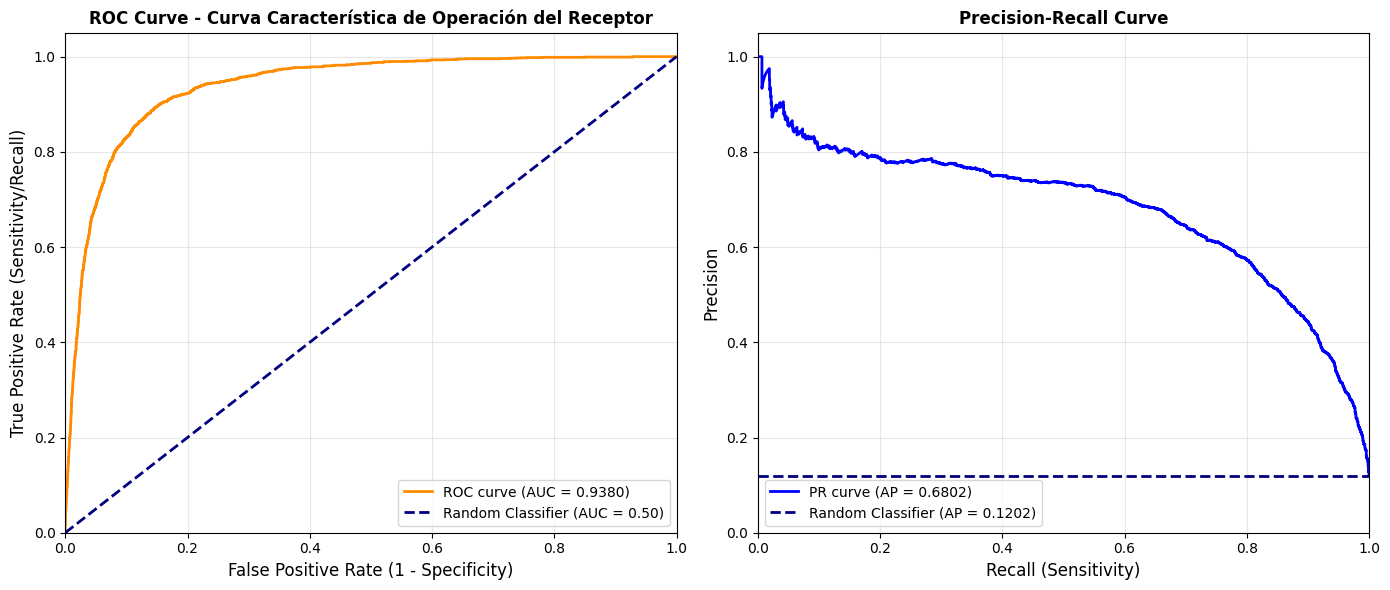


✅ Curvas guardadas en: figures/roc_pr_curves.png


In [9]:
# Visualizar ROC Curve y Precision-Recall Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
ax1.set_title('ROC Curve - Curva Característica de Operación del Receptor', fontsize=12, fontweight='bold')
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(alpha=0.3)

# Precision-Recall Curve
baseline_prevalence = y_true.mean()
ax2.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (AP = {auprc:.4f})')
ax2.axhline(y=baseline_prevalence, color='navy', lw=2, linestyle='--', 
            label=f'Random Classifier (AP = {baseline_prevalence:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(latest_run / 'figures' / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Curvas guardadas en: figures/roc_pr_curves.png")

## 7. Comparación con Estado del Arte

**Tabla de referencia para melanoma detection:**

| Métrica | Tu Modelo | Estado del Arte | Status |
|---------|-----------|-----------------|---------|
| AUROC | ? | 0.90 - 0.95 | ? |
| AUPRC | ? | 0.75 - 0.85 | ? |
| Sensitivity (Recall) | 80.4% | 85% - 95% | ⚠️ |
| Specificity | ? | 85% - 90% | ? |
| Accuracy | 89.4% | 88% - 92% | ✅ |

**⚠️ IMPORTANTE:** Accuracy sola NO es suficiente en datasets desbalanceados.
Las métricas AUROC y AUPRC son las que realmente importan para comparación.